# Analisis Sentimen Vibe Coding (Transformer)

Notebook ini melabeli sentimen tweet *vibe coding* memakai model multilingual
[`cardiffnlp/twitter-xlm-roberta-base-sentiment`](https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment).

Label keluaran: `negative`, `neutral`, `positive`.

**Alur:**
1. Setup dependensi
2. Muat data (lokal atau upload)
3. Preprocessing teks
4. Inferensi batch
5. Analisis: distribusi, tren per kuartal, sentimen per tool
6. Simpan hasil

Bisa dijalankan di Google Colab, VS Code, maupun Jupyter Lab.

## 1. Setup

Jalankan sel di bawah bila paket belum tersedia (mis. di Colab).

In [1]:
%pip install -q transformers torch sentencepiece protobuf pandas matplotlib seaborn ipywidgets scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.8 MB/s eta 0:00:0000:0100:01


In [2]:
import io
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.special import softmax
from transformers import AutoModelForSequenceClassification, AutoTokenizer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_colwidth", 160)

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
TEXT_COLUMN = "text"
DATE_COLUMN = "created_at"
BATCH_SIZE = 32
MAX_LENGTH = 128

# Batasi jumlah baris untuk uji cepat; None = seluruh data
N_ROWS = None

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch: 2.11.0+cu128 | CUDA: True


## 2. Muat Data

Sel **2a** mencari CSV di jalur lokal yang umum. Jika tidak ditemukan, ia menampilkan
widget upload. Setelah memilih file, jalankan sel **2b** untuk memprosesnya.

> Upload dan pemrosesan dipisah ke dua sel agar kernel tidak menggantung menunggu interaksi.

In [3]:
# --- 2a. Cari file lokal, atau tampilkan widget upload ---
CANDIDATE_PATHS = [
    "data/raw/vibecoding_relevant_10000.csv",
    "../data/raw/vibecoding_relevant_10000.csv",
    "vibecoding_relevant_10000.csv",
    "/content/vibecoding_relevant_10000.csv",
]

df = None
uploader = None

for path in CANDIDATE_PATHS:
    if os.path.exists(path):
        df = pd.read_csv(path, encoding="utf-8-sig")
        print(f"Dimuat dari: {path}")
        break

if df is None:
    import ipywidgets as widgets
    from IPython.display import display

    print("CSV lokal tidak ditemukan. Pilih file lewat widget di bawah,")
    print("lalu jalankan sel berikutnya (2b).")
    uploader = widgets.FileUpload(accept=".csv", multiple=False)
    display(uploader)
else:
    print(f"Ukuran: {df.shape}")
    print("Kolom:", df.columns.tolist())

CSV lokal tidak ditemukan. Pilih file lewat widget di bawah,
lalu jalankan sel berikutnya (2b).


FileUpload(value={}, accept='.csv', description='Upload')

In [4]:
# --- 2b. Proses file hasil upload (lewati jika data sudah dimuat di 2a) ---
if df is None:
    if uploader is None or not uploader.value:
        raise RuntimeError("Belum ada file terpilih. Pakai widget di sel 2a lalu ulangi sel ini.")

    # ipywidgets v7 -> dict {filename: {...}}; v8+ -> tuple of dicts dengan key 'name'
    if isinstance(uploader.value, dict):
        filename = next(iter(uploader.value))
        content = uploader.value[filename]["content"]
    else:
        item = uploader.value[0]
        filename = item["name"]
        content = item["content"]

    df = pd.read_csv(io.BytesIO(content), encoding="utf-8-sig")
    print(f"Dimuat dari upload: {filename}")

if N_ROWS is not None:
    df = df.head(N_ROWS).copy()
    print(f"Dibatasi ke {N_ROWS} baris pertama.")

print(f"Ukuran: {df.shape}")
print("Kolom:", df.columns.tolist())
df.head(3)

Dimuat dari upload: vibecoding_relevant_10000.csv
Ukuran: (10000, 13)
Kolom: ['collected_at', 'date_window_start', 'date_window_end', 'search_query', 'post_url', 'username', 'displayname', 'created_at', 'text', 'reply_count', 'repost_count', 'like_count', 'view_count']


,collected_at,date_window_start,date_window_end,search_query,post_url,username,displayname,created_at,text,reply_count,repost_count,like_count,view_count
0,2026-07-21T11:15:55.767090+00:00,2026-07-17,2026-07-22,"((""vibe coding"" OR vibecoding)) since:2026-07-17 until:2026-07-22",https://x.com/apify/status/2079525679905812988,apify,Apify,2026-07-21T11:15:32.000Z,"22dtk Vibe coding had a data problem. Your app came out beautiful - and full of lorem ipsum. Apify is now built into @macalycom . Describe your app, pick a ...",NaN,NaN,NaN,NaN
1,2026-07-21T11:15:55.854564+00:00,2026-07-17,2026-07-22,"((""vibe coding"" OR vibecoding)) since:2026-07-17 until:2026-07-22",https://x.com/edgarasben/status/2079525492751782021,edgarasben,Edgaras,2026-07-21T11:14:47.000Z,"I think it overloads agent's ""brain"" too. I don't trust them yet picking or not picking skills correctly. The best would be, if there are many skills and th...",NaN,NaN,NaN,NaN
2,2026-07-21T11:15:55.886657+00:00,2026-07-17,2026-07-22,"((""vibe coding"" OR vibecoding)) since:2026-07-17 until:2026-07-22",https://x.com/0xFsn_/status/2079525433901547677,0xFsn_,Fsn,2026-07-21T11:14:33.000Z,"I was about to do something similar, any chance that you share that and save my vibecoding time? 2",NaN,NaN,NaN,NaN


## 3. Preprocessing

Model dilatih pada teks Twitter, jadi pembersihan dijaga minimal: hanya URL dan
mention yang dinormalisasi. Emoji dan tanda baca dibiarkan karena membawa sinyal sentimen.

In [5]:
def clean_text(text):
    """Bersihkan teks tweet secara minimal untuk inferensi sentimen."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"https?://\S+", "", text)  # buang URL
    text = re.sub(r"@\w+", "", text)          # buang mention
    text = re.sub(r"\s+", " ", text).strip()  # rapikan spasi
    return text


df["text_clean"] = df[TEXT_COLUMN].apply(clean_text)

# Buang baris tanpa teks bermakna
before = len(df)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)
print(f"Dibuang {before - len(df)} baris kosong. Sisa: {len(df)}")

# Parse tanggal untuk analisis tren
if DATE_COLUMN in df.columns:
    df["created_dt"] = pd.to_datetime(df[DATE_COLUMN], errors="coerce", utc=True)
    df["quarter"] = df["created_dt"].dt.to_period("Q").astype(str)
    print("Rentang tanggal:", df["created_dt"].min(), "s/d", df["created_dt"].max())

df[[TEXT_COLUMN, "text_clean"]].head(5)

Dibuang 0 baris kosong. Sisa: 10000
Rentang tanggal: 2022-05-11 03:46:53+00:00 s/d 2026-07-21 20:22:49+00:00


/tmp/ipykernel_658/3744571080.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["quarter"] = df["created_dt"].dt.to_period("Q").astype(str)


,text,text_clean
0,"22dtk Vibe coding had a data problem. Your app came out beautiful - and full of lorem ipsum. Apify is now built into @macalycom . Describe your app, pick a ...","22dtk Vibe coding had a data problem. Your app came out beautiful - and full of lorem ipsum. Apify is now built into . Describe your app, pick a source, and..."
1,"I think it overloads agent's ""brain"" too. I don't trust them yet picking or not picking skills correctly. The best would be, if there are many skills and th...","I think it overloads agent's ""brain"" too. I don't trust them yet picking or not picking skills correctly. The best would be, if there are many skills and th..."
2,"I was about to do something similar, any chance that you share that and save my vibecoding time? 2","I was about to do something similar, any chance that you share that and save my vibecoding time? 2"
3,"GPT 5.6 Sol is the best model right now and its usage limits are pretty good (just don't use x-high or Ultra, trust me, you don't need it) You will probably...","GPT 5.6 Sol is the best model right now and its usage limits are pretty good (just don't use x-high or Ultra, trust me, you don't need it) You will probably..."
4,"Once upon a time, in an AI-native kingdom just past the last vector database, a lovable little AI reasoning model named Claude couldn’t sleep. Its context w...","Once upon a time, in an AI-native kingdom just past the last vector database, a lovable little AI reasoning model named Claude couldn’t sleep. Its context w..."


## 4. Muat Model

In [6]:
print(f"Memuat {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Device:", device)

# id2label bawaan model: 0=negative, 1=neutral, 2=positive
LABELS = [model.config.id2label[i].lower() for i in range(model.config.num_labels)]
print("Label:", LABELS)

Memuat cardiffnlp/twitter-xlm-roberta-base-sentiment ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Device: cuda
Label: ['negative', 'neutral', 'positive']


## 5. Inferensi Batch

In [7]:
def predict_sentiment(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    """Kembalikan (labels, scores, probs) untuk daftar teks."""
    labels, scores, all_probs = [], [], []
    n_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            print(f"  batch {i // batch_size + 1}/{n_batches}", end="\r")

            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            ).to(device)

            logits = model(**encoded).logits.cpu().numpy()
            probs = softmax(logits, axis=1)

            for row in probs:
                idx = int(row.argmax())
                labels.append(LABELS[idx])
                scores.append(float(row[idx]))
                all_probs.append(row)

    print()
    return labels, scores, np.vstack(all_probs)


texts = df["text_clean"].tolist()
print(f"Inferensi {len(texts)} teks ...")
labels, scores, probs = predict_sentiment(texts)

df["sentiment"] = labels
df["sentiment_score"] = scores
for i, name in enumerate(LABELS):
    df[f"prob_{name}"] = probs[:, i]

print("Selesai.")
df[[TEXT_COLUMN, "sentiment", "sentiment_score"]].head(10)

Inferensi 10000 teks ...
  batch 313/313
Selesai.


,text,sentiment,sentiment_score
0,"22dtk Vibe coding had a data problem. Your app came out beautiful - and full of lorem ipsum. Apify is now built into @macalycom . Describe your app, pick a ...",positive,0.442278
1,"I think it overloads agent's ""brain"" too. I don't trust them yet picking or not picking skills correctly. The best would be, if there are many skills and th...",negative,0.521366
2,"I was about to do something similar, any chance that you share that and save my vibecoding time? 2",neutral,0.496833
3,"GPT 5.6 Sol is the best model right now and its usage limits are pretty good (just don't use x-high or Ultra, trust me, you don't need it) You will probably...",positive,0.560413
4,"Once upon a time, in an AI-native kingdom just past the last vector database, a lovable little AI reasoning model named Claude couldn’t sleep. Its context w...",neutral,0.406821
5,Working with c++ after a long time. Building a vibecoding tool for non-coders! 1 4,positive,0.654355
6,Times have changed old man. You'll never be able to escape vibecoding. 3,negative,0.547491
7,"yeah, in production, we don't have as many bells and whistles or such styled components. this is more of my personal exploration of the possibilities i can ...",positive,0.618324
8,"KEMENTERIAN DIGITAL PERKASA LITERASI AI MENERUSI BENGKEL VIBE CODING 101 DI PDX2026 PULAU PINANG, 15 Julai 2026 – Kementerian Digital telah menyertai Penang...",neutral,0.794746
9,"Vibe coding as a first steps allows me to iterate really fast on potential implementation ideas and UX, so I can avoid mistakes in the laster phase when I a...",positive,0.619623


## 6. Distribusi Sentimen

Distribusi sentimen
----------------------------------
positive     2725  ( 27.3%)
neutral      5246  ( 52.5%)
negative     2029  ( 20.3%)
----------------------------------
total       10000


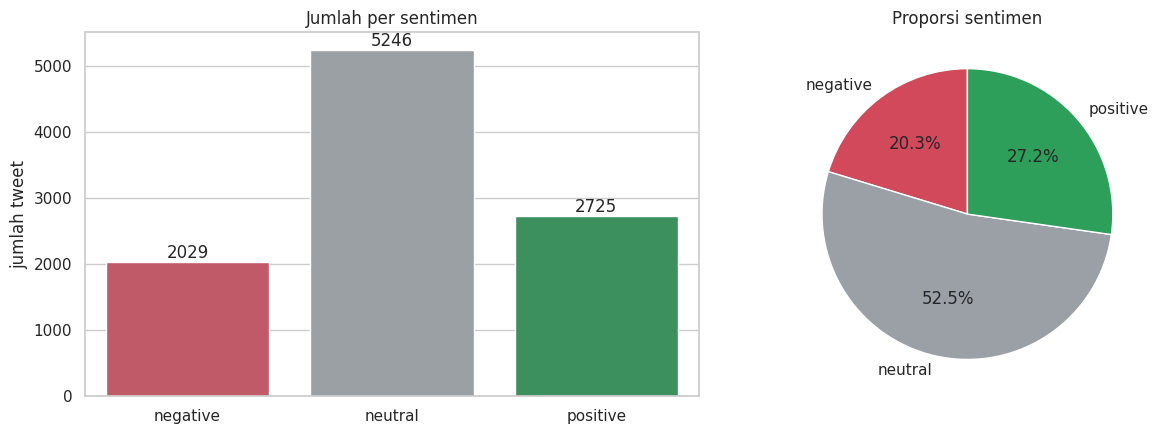

In [8]:
counts = df["sentiment"].value_counts()
pcts = (counts / len(df) * 100).round(1)

print("Distribusi sentimen")
print("-" * 34)
for label in ["positive", "neutral", "negative"]:
    if label in counts:
        print(f"{label:<10} {counts[label]:>6}  ({pcts[label]:>5.1f}%)")
print("-" * 34)
print(f"{'total':<10} {len(df):>6}")

palette = {"positive": "#2e9e5b", "neutral": "#9aa0a6", "negative": "#d1495b"}
order = [l for l in ["negative", "neutral", "positive"] if l in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(x=order, y=[counts[l] for l in order], hue=order,
            palette=palette, legend=False, ax=axes[0])
axes[0].set_title("Jumlah per sentimen")
axes[0].set_ylabel("jumlah tweet")
for i, l in enumerate(order):
    axes[0].text(i, counts[l], f"{counts[l]}", ha="center", va="bottom")

axes[1].pie([counts[l] for l in order], labels=order, autopct="%1.1f%%",
            colors=[palette[l] for l in order], startangle=90)
axes[1].set_title("Proporsi sentimen")

plt.tight_layout()
plt.show()

            count   mean    std    min    25%    50%    75%    max
sentiment                                                         
negative   2029.0  0.671  0.175  0.345  0.510  0.665  0.834  0.964
neutral    5246.0  0.592  0.123  0.338  0.495  0.578  0.678  0.944
positive   2725.0  0.616  0.138  0.346  0.504  0.598  0.726  0.940


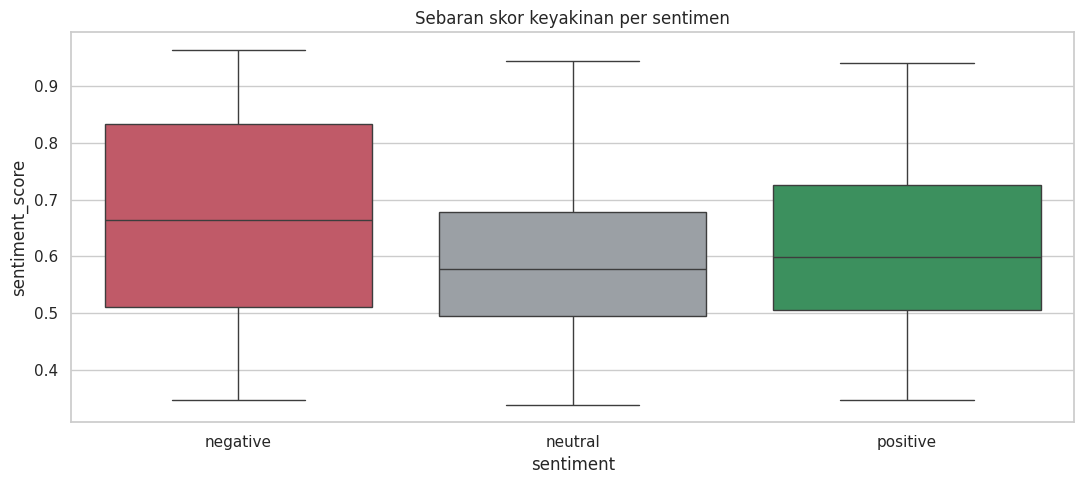


Prediksi keyakinan rendah (<0.50): 2501 (25.0%)


In [9]:
# Sebaran skor keyakinan per label
print(df.groupby("sentiment")["sentiment_score"].describe().round(3))

sns.boxplot(data=df, x="sentiment", y="sentiment_score", order=order,
            hue="sentiment", palette=palette, legend=False)
plt.title("Sebaran skor keyakinan per sentimen")
plt.tight_layout()
plt.show()

low_conf = df[df["sentiment_score"] < 0.5]
print(f"\nPrediksi keyakinan rendah (<0.50): {len(low_conf)} ({len(low_conf) / len(df) * 100:.1f}%)")

## 7. Contoh Tweet per Sentimen

In [10]:
for label in order:
    subset = df[df["sentiment"] == label].nlargest(5, "sentiment_score")
    print("=" * 100)
    print(f"{label.upper()} — 5 contoh dengan keyakinan tertinggi")
    print("=" * 100)
    for _, row in subset.iterrows():
        print(f"[{row['sentiment_score']:.3f}] {row['text_clean'][:280]}")
        print()

NEGATIVE — 5 contoh dengan keyakinan tertinggi
[0.964] elasticsearch is the worst. i can’t possibly buy tech i use every day at work. ES is so ass… this whole vibe coding boom is causing people to make shit choices 6 4 283

[0.961] Please stop perpetuating this shitty gen Z slang "vibe coding". I hate it. 3 10 2 rb

[0.959] dan I also just think the term "vibe coding" sucks and I wish it were something else. Like... PURE "vibes only" coding would be silly and really doesn't get very far. But vibe coding encompasses a lot more than just LLM assisted auto complete...etc. 1 2 180

[0.958] Anthropic made a rollback of 12 months with Claude Code. It's really a pitty. Are they just happily vibe coding? Without any testing? 1 2 305

[0.957] 30 Jan trump, ai, enn eff tee, cr*pto, vibe coding, elon twitter all absolutely clear and frankly sec burner twitter but you're right outside of the sides of twitter that are all roasting in hell soon it's the worst it's so fucking lame 1 6 170

NEUTRAL — 

## 8. Tren Sentimen per Kuartal

Jumlah per kuartal
sentiment  negative  neutral  positive
quarter                               
2022Q2            0        1         0
2023Q3            0        1         0
2024Q1            0        1         0
2025Q1          285      671       376
2025Q2          206      586       348
2025Q3          457     1150       729
2025Q4          157      497       282
2026Q1          364      905       418
2026Q2          335      975       393
2026Q3          225      459       179

Persentase per kuartal
sentiment  negative  neutral  positive
quarter                               
2022Q2          0.0    100.0       0.0
2023Q3          0.0    100.0       0.0
2024Q1          0.0    100.0       0.0
2025Q1         21.4     50.4      28.2
2025Q2         18.1     51.4      30.5
2025Q3         19.6     49.2      31.2
2025Q4         16.8     53.1      30.1
2026Q1         21.6     53.6      24.8
2026Q2         19.7     57.3      23.1
2026Q3         26.1     53.2      20.7


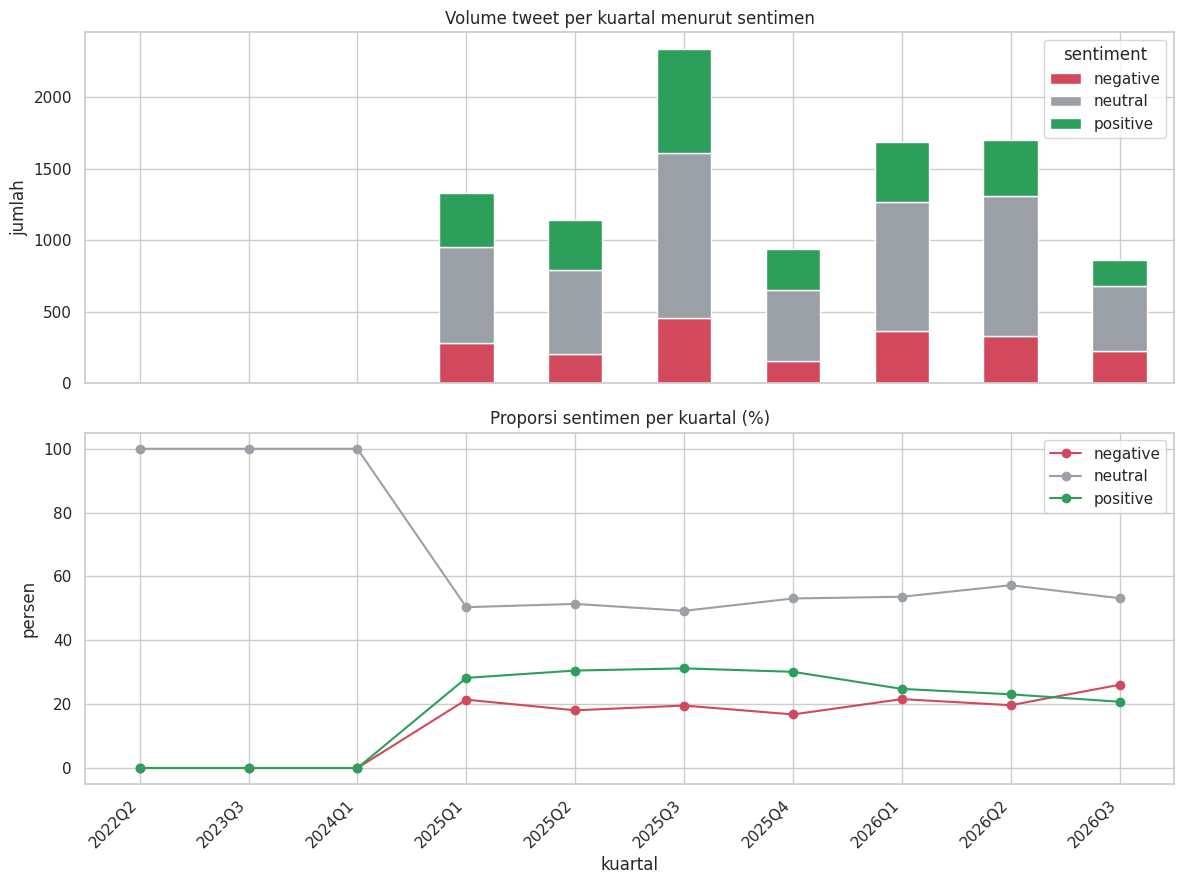

In [11]:
if "quarter" in df.columns:
    quarterly = (
        df.dropna(subset=["created_dt"])
        .groupby(["quarter", "sentiment"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )
    quarterly_pct = quarterly.div(quarterly.sum(axis=1), axis=0) * 100

    print("Jumlah per kuartal")
    print(quarterly)
    print("\nPersentase per kuartal")
    print(quarterly_pct.round(1))

    cols = [c for c in order if c in quarterly.columns]
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

    quarterly[cols].plot(kind="bar", stacked=True,
                         color=[palette[c] for c in cols], ax=axes[0])
    axes[0].set_title("Volume tweet per kuartal menurut sentimen")
    axes[0].set_ylabel("jumlah")

    for c in cols:
        axes[1].plot(quarterly_pct.index, quarterly_pct[c],
                     marker="o", color=palette[c], label=c)
    axes[1].set_title("Proporsi sentimen per kuartal (%)")
    axes[1].set_ylabel("persen")
    axes[1].set_xlabel("kuartal")
    axes[1].legend()
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print(f"Kolom '{DATE_COLUMN}' tidak ada, analisis tren dilewati.")

## 9. Sentimen per Tool

Bandingkan nada pembicaraan untuk tiap tool AI coding yang disebut dalam tweet.

          tool    n  positive_%  neutral_%  negative_%  net_sentiment
       Lovable  316        39.2       48.1        12.7           26.5
        Replit  259        35.5       49.4        15.1           20.4
      Windsurf   77        35.1       49.4        15.6           19.5
 Gemini/Google  325        29.8       57.2        12.9           16.9
          Bolt  116        26.7       62.9        10.3           16.4
       Copilot  102        26.5       60.8        12.7           13.8
ChatGPT/OpenAI  453        27.6       58.1        14.3           13.3
        Cursor  763        24.2       57.5        18.2            6.0
        Claude 1304        25.1       53.8        21.2            3.9


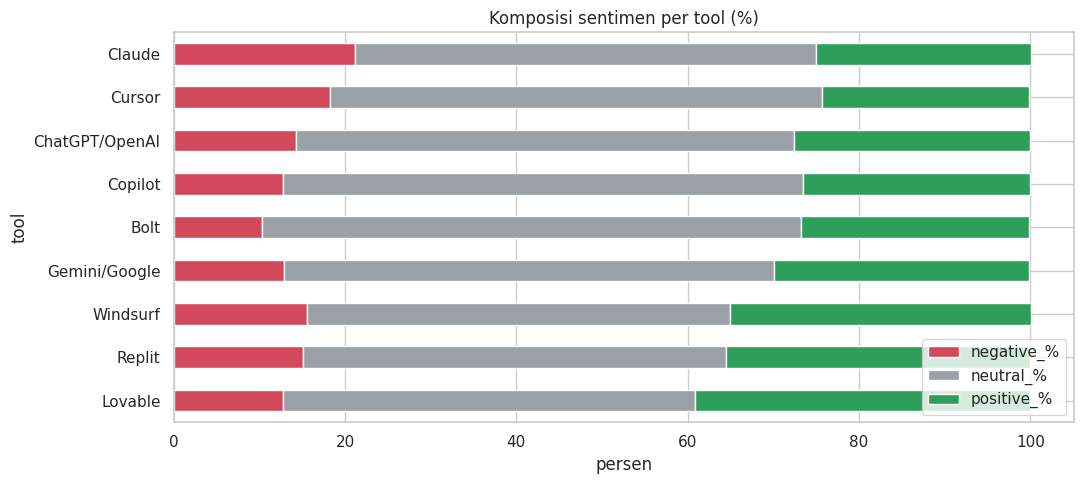

In [12]:
TOOL_PATTERNS = {
    "Claude": r"\bclaude\b|claude code",
    "Cursor": r"\bcursor\b",
    "Copilot": r"\bcopilot\b",
    "Replit": r"\breplit\b",
    "Lovable": r"\blovable\b",
    "Bolt": r"\bbolt\.?new\b|\bbolt\b",
    "ChatGPT/OpenAI": r"\bchatgpt\b|\bopenai\b|\bcodex\b",
    "Gemini/Google": r"\bgemini\b|ai studio|antigravity",
    "Windsurf": r"\bwindsurf\b",
}

rows = []
lowered = df["text_clean"].str.lower()

for tool, pattern in TOOL_PATTERNS.items():
    mask = lowered.str.contains(pattern, regex=True, na=False)
    sub = df[mask]
    if len(sub) < 10:  # abaikan sampel terlalu kecil
        continue
    vc = sub["sentiment"].value_counts(normalize=True) * 100
    rows.append({
        "tool": tool,
        "n": len(sub),
        "positive_%": round(vc.get("positive", 0), 1),
        "neutral_%": round(vc.get("neutral", 0), 1),
        "negative_%": round(vc.get("negative", 0), 1),
    })

tool_df = pd.DataFrame(rows)
if not tool_df.empty:
    tool_df["net_sentiment"] = (tool_df["positive_%"] - tool_df["negative_%"]).round(1)
    tool_df = tool_df.sort_values("net_sentiment", ascending=False).reset_index(drop=True)
    print(tool_df.to_string(index=False))

    plot_df = tool_df.set_index("tool")[["negative_%", "neutral_%", "positive_%"]]
    plot_df.plot(kind="barh", stacked=True,
                 color=[palette["negative"], palette["neutral"], palette["positive"]])
    plt.title("Komposisi sentimen per tool (%)")
    plt.xlabel("persen")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada tool dengan sampel memadai (minimal 10 tweet).")

## 10. Sentimen vs Engagement

Apakah tweet negatif mendapat engagement lebih tinggi daripada tweet positif?

Engagement menurut sentimen
          reply_count        repost_count        like_count        view_count  \
                 mean median         mean median       mean median       mean   
sentiment                                                                       
negative          NaN    NaN          NaN    NaN        NaN    NaN        NaN   
neutral         101.0  101.0          NaN    NaN        NaN    NaN        NaN   
positive          NaN    NaN          NaN    NaN        2.0    2.0        2.0   

                  
          median  
sentiment         
negative     NaN  
neutral      NaN  
positive     2.0  


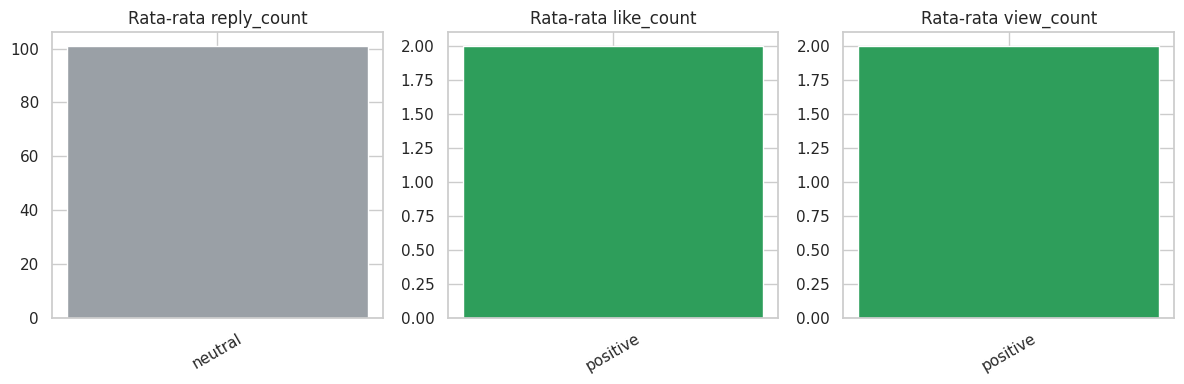

In [13]:
engagement_cols = [c for c in ["reply_count", "repost_count", "like_count", "view_count"]
                   if c in df.columns]

if engagement_cols:
    eng = df.copy()
    for c in engagement_cols:
        eng[c] = pd.to_numeric(eng[c], errors="coerce")

    summary = eng.groupby("sentiment")[engagement_cols].agg(["mean", "median"]).round(1)
    print("Engagement menurut sentimen")
    print(summary)

    valid = [c for c in engagement_cols if eng[c].notna().sum() > 0]
    if valid:
        fig, axes = plt.subplots(1, len(valid), figsize=(4 * len(valid), 4))
        axes = np.atleast_1d(axes)
        for ax, c in zip(axes, valid):
            means = eng.groupby("sentiment")[c].mean().reindex(order).dropna()
            ax.bar(means.index, means.values, color=[palette[i] for i in means.index])
            ax.set_title(f"Rata-rata {c}")
            ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()
else:
    print("Kolom engagement tidak tersedia.")

## 11. Simpan Hasil

In [14]:
OUTPUT_CSV = "vibecoding_sentimen_labeled.csv"

export_cols = [c for c in df.columns if c != "created_dt"]
df[export_cols].to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"Disimpan: {OUTPUT_CSV}  ({len(df)} baris)")

# Di Colab, unduh otomatis
try:
    from google.colab import files

    files.download(OUTPUT_CSV)
except Exception:
    print("(Bukan Colab — file tersimpan lokal.)")

Disimpan: vibecoding_sentimen_labeled.csv  (10000 baris)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Catatan

- Model bersifat multilingual (~8 bahasa terlatih), cocok untuk dataset campuran
  Inggris/Indonesia/Spanyol/Jepang pada korpus ini.
- `MAX_LENGTH = 128` token memotong tweet yang sangat panjang (mis. yang menyertakan
  teks kutipan). Naikkan ke 256 bila ingin konteks lebih penuh, dengan biaya waktu inferensi.
- Prediksi berkeyakinan rendah (`sentiment_score < 0.5`) sebaiknya ditinjau manual bila
  hasil dipakai untuk klaim kuantitatif.
- Ironi dan sarkasme tetap sulit; tweet seperti *"vibe coding is amazing until production crashes"*
  sering terklasifikasi kurang tepat.